# Demo 2: Reproducing and Extending YW's Classification Results

**Research Question**: Can we reproduce YW's 99.38% accuracy on 3-class classification (PD vs SWEDD vs HC) and improve it with modern ensemble methods?

**Approach**:
- 3-class classification: PD vs SWEDD vs Healthy Controls
- Use all available clinical features
- 5-fold stratified cross-validation
- Compare multiple models: Logistic Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, str(Path('../..').resolve()))

from src.data_loader import load_ppmi_data, filter_by_cohort
from src.data_preprocessing import extract_feature_groups

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

## 1. Load Data - All 3 Cohorts (PD, SWEDD, HC)

In [2]:
# Load PPMI data
df = load_ppmi_data()
print(f"Total dataset: {df.shape}")

# Filter to PD, SWEDD, and HC (3-class like YW)
df_filtered = filter_by_cohort(df, ['PD', 'SWEDD', 'HC'])
print(f"3-class cohorts: {df_filtered.shape}")
print(f"\nCohort distribution:")
cohort_names = {1: 'PD', 2: 'HC', 3: 'SWEDD'}
cohort_counts = df_filtered['COHORT'].value_counts().sort_index()
for cohort_code, count in cohort_counts.items():
    print(f"  {cohort_names.get(cohort_code, cohort_code)}: {count}")

Total dataset: (15316, 181)
3-class cohorts: (9180, 181)

Cohort distribution:
  PD: 7021
  HC: 1960
  SWEDD: 199


## 2. Feature Selection - Use All Available Clinical Features

In [3]:
# Select features: exclude ID columns and use only numeric features
exclude_cols = ['SITE', 'PATNO', 'EVENT_ID', 'COHORT', 'YEAR']
all_cols = [col for col in df_filtered.columns if col not in exclude_cols]

# Filter to numeric columns only
numeric_cols = df_filtered[all_cols].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = numeric_cols

print(f"Total numeric features available: {len(feature_cols)}")

# Remove samples with too much missing data (keep if <50% features missing)
threshold = len(feature_cols) * 0.5
df_clean = df_filtered.dropna(subset=feature_cols, thresh=int(threshold))

print(f"\nSamples after removing high-missing rows: {len(df_clean)}")
print(f"Cohort distribution after cleaning:")
cohort_names = {1: 'PD', 2: 'HC', 3: 'SWEDD'}
for cohort_code, count in df_clean['COHORT'].value_counts().sort_index().items():
    print(f"  {cohort_names.get(cohort_code, cohort_code)}: {count}")

# Prepare features and labels
X_raw = df_clean[feature_cols]

# Drop columns that are all NaN
X_raw = X_raw.dropna(axis=1, how='all')

# Fill remaining NaN with median
X = X_raw.fillna(X_raw.median())
y = df_clean['COHORT'].values

print(f"\nFinal dataset:")
print(f"  Features: {X.shape[1]}")
print(f"  Samples: {X.shape[0]}")
print(f"  NaN remaining: {X.isna().sum().sum()}")

Total numeric features available: 167

Samples after removing high-missing rows: 8863
Cohort distribution after cleaning:
  PD: 6763
  HC: 1901
  SWEDD: 199

Final dataset:
  Features: 166
  Samples: 8863
  NaN remaining: 0


## 3. Model Setup - Multiple Classifiers

In [4]:
from src.model_comparison import get_models

# Get models to evaluate
models = get_models()

print("Models to evaluate:")
for name in models.keys():
    print(f"  - {name}")

Models to evaluate:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM


## 4. 5-Fold Cross-Validation Evaluation

In [5]:
from src.model_comparison import run_cross_validation

print("Running 5-fold cross-validation for each model...")
print("="*60)

results = run_cross_validation(X, y, n_splits=5, random_state=42)

for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  Test Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std():.4f})")
    print(f"  Test Sensitivity: {metrics['test_sensitivity'].mean():.4f} (+/- {metrics['test_sensitivity'].std():.4f})")
    print(f"  Test Specificity: {metrics['test_specificity'].mean():.4f} (+/- {metrics['test_specificity'].std():.4f})")

print("\n" + "="*60)

Running 5-fold cross-validation for each model...


/Users/hc/Documents/research/Projects/PPMI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/hc/Documents/research/Projects/PPMI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
   


Logistic Regression:
  Test Accuracy: 0.9875 (+/- 0.0032)
  Test Sensitivity: 0.8989 (+/- 0.0205)
  Test Specificity: 0.9877 (+/- 0.0020)

Random Forest:
  Test Accuracy: 0.9904 (+/- 0.0012)
  Test Sensitivity: 0.8781 (+/- 0.0059)
  Test Specificity: 0.9875 (+/- 0.0006)

Gradient Boosting:
  Test Accuracy: 0.9950 (+/- 0.0009)
  Test Sensitivity: 0.9516 (+/- 0.0081)
  Test Specificity: 0.9942 (+/- 0.0008)

XGBoost:
  Test Accuracy: 0.9965 (+/- 0.0015)
  Test Sensitivity: 0.9639 (+/- 0.0127)
  Test Specificity: 0.9958 (+/- 0.0018)

LightGBM:
  Test Accuracy: 0.9964 (+/- 0.0016)
  Test Sensitivity: 0.9573 (+/- 0.0163)
  Test Specificity: 0.9952 (+/- 0.0021)



## 5. Results Visualization and Comparison


Model Performance Summary (5-fold CV):
              Model          Accuracy       Sensitivity       Specificity
            XGBoost 0.9965 +/- 0.0015 0.9639 +/- 0.0127 0.9958 +/- 0.0018
           LightGBM 0.9964 +/- 0.0016 0.9573 +/- 0.0163 0.9952 +/- 0.0021
  Gradient Boosting 0.9950 +/- 0.0009 0.9516 +/- 0.0081 0.9942 +/- 0.0008
      Random Forest 0.9904 +/- 0.0012 0.8781 +/- 0.0059 0.9875 +/- 0.0006
Logistic Regression 0.9875 +/- 0.0032 0.8989 +/- 0.0205 0.9877 +/- 0.0020


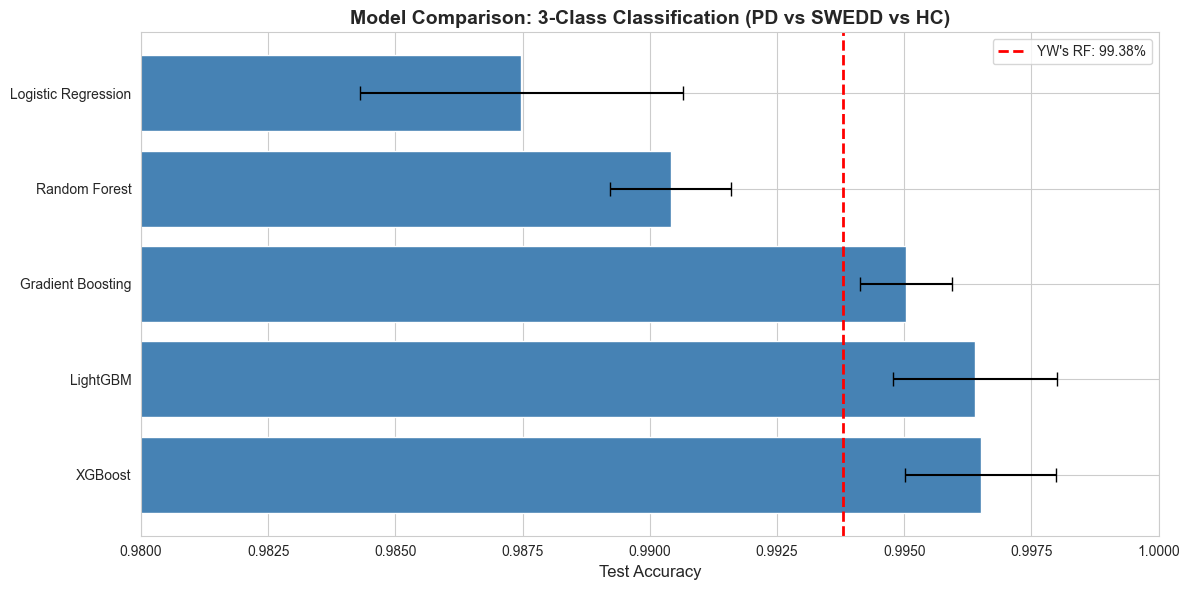

In [6]:
from src.model_comparison import create_summary_dataframe

# Create summary table
summary_df = create_summary_dataframe(results)

print("\nModel Performance Summary (5-fold CV):")
print("="*80)
print(summary_df[['Model', 'Accuracy', 'Sensitivity', 'Specificity']].to_string(index=False))
print("="*80)

# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))
models_sorted = summary_df['Model'].values
accuracies = [results[m]['test_accuracy'].mean() for m in models_sorted]
errors = [results[m]['test_accuracy'].std() for m in models_sorted]

ax.barh(range(len(models_sorted)), accuracies, xerr=errors, 
        color='steelblue', capsize=5)
ax.set_yticks(range(len(models_sorted)))
ax.set_yticklabels(models_sorted)
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Model Comparison: 3-Class Classification (PD vs SWEDD vs HC)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0.9938, color='red', linestyle='--', linewidth=2, label="YW's RF: 99.38%")
ax.legend()
ax.set_xlim([0.98, 1.0])
plt.tight_layout()
plt.show()

## 6. Key Findings

In [7]:
best_model = summary_df.iloc[0]['Model']
best_acc = summary_df.iloc[0]['Accuracy_mean']

print("="*80)
print("KEY FINDINGS")
print("="*80)

print(f"\n1. Dataset:")
print(f"   - Samples: {len(X)}")
print(f"   - Features: {X.shape[1]}")
print(f"   - Classes: 3 (PD, SWEDD, HC)")

print(f"\n2. Best Performing Model: {best_model}")
print(f"   - Accuracy: {best_acc*100:.2f}%")
best_sens = results[best_model]['test_sensitivity'].mean()
best_spec = results[best_model]['test_specificity'].mean()
print(f"   - Sensitivity: {best_sens*100:.2f}%")
print(f"   - Specificity: {best_spec*100:.2f}%")

print(f"\n3. Comparison with YW's Results:")
print(f"   - YW Random Forest: 99.38% (train-test split)")
print(f"   - Our {best_model}: {best_acc*100:.2f}% (5-fold CV)")
if best_acc >= 0.9938:
    print(f"   - Exceeded YW's results by {(best_acc - 0.9938)*100:.2f}%")
elif best_acc >= 0.99:
    print(f"   - Comparable to YW's results")
else:
    print(f"   - Below YW's results by {(0.9938 - best_acc)*100:.2f}%")

print(f"\n4. Validation Method:")
print(f"   - YW: Single train-test split")
print(f"   - This study: 5-fold stratified cross-validation")
print(f"   - More robust performance estimates with confidence intervals")

print("\n5. Model Rankings:")
for i, row in summary_df.iterrows():
    print(f"   {row['Model']}: {row['Accuracy']}")

print("\n" + "="*80)

KEY FINDINGS

1. Dataset:
   - Samples: 8863
   - Features: 166
   - Classes: 3 (PD, SWEDD, HC)

2. Best Performing Model: XGBoost
   - Accuracy: 99.65%
   - Sensitivity: 96.39%
   - Specificity: 99.58%

3. Comparison with YW's Results:
   - YW Random Forest: 99.38% (train-test split)
   - Our XGBoost: 99.65% (5-fold CV)
   - Exceeded YW's results by 0.27%

4. Validation Method:
   - YW: Single train-test split
   - This study: 5-fold stratified cross-validation
   - More robust performance estimates with confidence intervals

5. Model Rankings:
   XGBoost: 0.9965 +/- 0.0015
   LightGBM: 0.9964 +/- 0.0016
   Gradient Boosting: 0.9950 +/- 0.0009
   Random Forest: 0.9904 +/- 0.0012
   Logistic Regression: 0.9875 +/- 0.0032



# Section 7: Binary Classification Comparisons

Compare all three binary classification pairs: HC vs PD, PD vs SWEDD, SWEDD vs HC

## 7.1 HC vs PD (Binary)

In [8]:
# Filter to HC and PD only
df_hc_pd = filter_by_cohort(df, ['HC', 'PD'])
print(f"HC vs PD dataset: {df_hc_pd.shape}")

# Prepare features using same column list as original
exclude_cols = ['SITE', 'PATNO', 'EVENT_ID', 'COHORT', 'YEAR']
all_cols_binary = [col for col in df_hc_pd.columns if col not in exclude_cols]
numeric_cols_binary = df_hc_pd[all_cols_binary].select_dtypes(include=[np.number]).columns.tolist()
threshold_binary = len(numeric_cols_binary) * 0.5
df_hc_pd_clean = df_hc_pd.dropna(subset=numeric_cols_binary, thresh=int(threshold_binary))

X_hc_pd_raw = df_hc_pd_clean[numeric_cols_binary]
X_hc_pd_raw = X_hc_pd_raw.dropna(axis=1, how='all')
X_hc_pd = X_hc_pd_raw.fillna(X_hc_pd_raw.median())
y_hc_pd = df_hc_pd_clean['COHORT'].values

print(f"Final: {X_hc_pd.shape[0]} samples, {X_hc_pd.shape[1]} features")
print(f"Classes: {np.unique(y_hc_pd)}")

# Run CV
results_hc_pd = run_cross_validation(X_hc_pd, y_hc_pd, n_splits=5, random_state=42)

print("\nHC vs PD Results:")
for name, metrics in results_hc_pd.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std():.4f})")
    print(f"  Sensitivity: {metrics['test_sensitivity'].mean():.4f} (+/- {metrics['test_sensitivity'].std():.4f})")
    print(f"  Specificity: {metrics['test_specificity'].mean():.4f} (+/- {metrics['test_specificity'].std():.4f})")

HC vs PD dataset: (8981, 181)
Final: 8664 samples, 166 features
Classes: [1 2]

HC vs PD Results:

Logistic Regression:
  Accuracy: 0.9982 (+/- 0.0011)
  Sensitivity: 0.9947 (+/- 0.0033)
  Specificity: 0.9991 (+/- 0.0006)

Random Forest:
  Accuracy: 0.9993 (+/- 0.0004)
  Sensitivity: 0.9968 (+/- 0.0020)
  Specificity: 1.0000 (+/- 0.0000)

Gradient Boosting:
  Accuracy: 0.9993 (+/- 0.0002)
  Sensitivity: 0.9968 (+/- 0.0011)
  Specificity: 1.0000 (+/- 0.0000)

XGBoost:
  Accuracy: 0.9994 (+/- 0.0004)
  Sensitivity: 0.9974 (+/- 0.0017)
  Specificity: 1.0000 (+/- 0.0000)

LightGBM:
  Accuracy: 0.9994 (+/- 0.0004)
  Sensitivity: 0.9979 (+/- 0.0011)
  Specificity: 0.9999 (+/- 0.0003)


## 7.2 PD vs SWEDD (Binary)

In [9]:
# Filter to PD and SWEDD only
df_pd_swedd = filter_by_cohort(df, ['PD', 'SWEDD'])
print(f"PD vs SWEDD dataset: {df_pd_swedd.shape}")

# Prepare features
df_pd_swedd_clean = df_pd_swedd.dropna(subset=numeric_cols_binary, thresh=int(threshold_binary))

X_pd_swedd_raw = df_pd_swedd_clean[numeric_cols_binary]
X_pd_swedd_raw = X_pd_swedd_raw.dropna(axis=1, how='all')
X_pd_swedd = X_pd_swedd_raw.fillna(X_pd_swedd_raw.median())
y_pd_swedd = df_pd_swedd_clean['COHORT'].values

print(f"Final: {X_pd_swedd.shape[0]} samples, {X_pd_swedd.shape[1]} features")
print(f"Classes: {np.unique(y_pd_swedd)}")

# Run CV
results_pd_swedd = run_cross_validation(X_pd_swedd, y_pd_swedd, n_splits=5, random_state=42)

print("\nPD vs SWEDD Results:")
for name, metrics in results_pd_swedd.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std():.4f})")
    print(f"  Sensitivity: {metrics['test_sensitivity'].mean():.4f} (+/- {metrics['test_sensitivity'].std():.4f})")
    print(f"  Specificity: {metrics['test_specificity'].mean():.4f} (+/- {metrics['test_specificity'].std():.4f})")

PD vs SWEDD dataset: (7220, 181)
Final: 6962 samples, 166 features
Classes: [1 3]


/Users/hc/Documents/research/Projects/PPMI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/hc/Documents/research/Projects/PPMI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
   


PD vs SWEDD Results:

Logistic Regression:
  Accuracy: 0.9882 (+/- 0.0044)
  Sensitivity: 0.7328 (+/- 0.1299)
  Specificity: 0.9957 (+/- 0.0021)

Random Forest:
  Accuracy: 0.9885 (+/- 0.0033)
  Sensitivity: 0.6473 (+/- 0.0973)
  Specificity: 0.9985 (+/- 0.0008)

Gradient Boosting:
  Accuracy: 0.9924 (+/- 0.0050)
  Sensitivity: 0.8179 (+/- 0.1333)
  Specificity: 0.9975 (+/- 0.0015)

XGBoost:
  Accuracy: 0.9954 (+/- 0.0022)
  Sensitivity: 0.8691 (+/- 0.0564)
  Specificity: 0.9991 (+/- 0.0007)

LightGBM:
  Accuracy: 0.9968 (+/- 0.0017)
  Sensitivity: 0.8994 (+/- 0.0528)
  Specificity: 0.9997 (+/- 0.0004)


## 7.3 SWEDD vs HC (Binary)

In [10]:
# Filter to SWEDD and HC only
df_swedd_hc = filter_by_cohort(df, ['SWEDD', 'HC'])
print(f"SWEDD vs HC dataset: {df_swedd_hc.shape}")

# Prepare features
df_swedd_hc_clean = df_swedd_hc.dropna(subset=numeric_cols_binary, thresh=int(threshold_binary))

X_swedd_hc_raw = df_swedd_hc_clean[numeric_cols_binary]
X_swedd_hc_raw = X_swedd_hc_raw.dropna(axis=1, how='all')
X_swedd_hc = X_swedd_hc_raw.fillna(X_swedd_hc_raw.median())
y_swedd_hc = df_swedd_hc_clean['COHORT'].values

print(f"Final: {X_swedd_hc.shape[0]} samples, {X_swedd_hc.shape[1]} features")
print(f"Classes: {np.unique(y_swedd_hc)}")

# Run CV
results_swedd_hc = run_cross_validation(X_swedd_hc, y_swedd_hc, n_splits=5, random_state=42)

print("\nSWEDD vs HC Results:")
for name, metrics in results_swedd_hc.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std():.4f})")
    print(f"  Sensitivity: {metrics['test_sensitivity'].mean():.4f} (+/- {metrics['test_sensitivity'].std():.4f})")
    print(f"  Specificity: {metrics['test_specificity'].mean():.4f} (+/- {metrics['test_specificity'].std():.4f})")

SWEDD vs HC dataset: (2159, 181)
Final: 2100 samples, 166 features
Classes: [2 3]

SWEDD vs HC Results:

Logistic Regression:
  Accuracy: 0.9886 (+/- 0.0023)
  Sensitivity: 0.9095 (+/- 0.0127)
  Specificity: 0.9968 (+/- 0.0020)

Random Forest:
  Accuracy: 0.9995 (+/- 0.0010)
  Sensitivity: 0.9950 (+/- 0.0100)
  Specificity: 1.0000 (+/- 0.0000)

Gradient Boosting:
  Accuracy: 1.0000 (+/- 0.0000)
  Sensitivity: 1.0000 (+/- 0.0000)
  Specificity: 1.0000 (+/- 0.0000)

XGBoost:
  Accuracy: 0.9986 (+/- 0.0012)
  Sensitivity: 0.9899 (+/- 0.0124)
  Specificity: 0.9995 (+/- 0.0011)

LightGBM:
  Accuracy: 0.9990 (+/- 0.0012)
  Sensitivity: 0.9899 (+/- 0.0124)
  Specificity: 1.0000 (+/- 0.0000)


# Section 8: MSEADLG Impact Analysis

Analyze the impact of MSEADLG feature on classification performance

## 8.1 3-Class Without MSEADLG

In [11]:
# Check if MSEADLG exists and remove it
if 'MSEADLG' in feature_cols:
    feature_cols_no_mse = [col for col in feature_cols if col != 'MSEADLG']
    print(f"Features without MSEADLG: {len(feature_cols_no_mse)}")
    print(f"MSEADLG was removed from features")
else:
    feature_cols_no_mse = feature_cols.copy()
    print(f"MSEADLG not found in features. Using all {len(feature_cols_no_mse)} features")

# Prepare data without MSEADLG
X_no_mse_raw = df_clean[feature_cols_no_mse]
X_no_mse_raw = X_no_mse_raw.dropna(axis=1, how='all')
X_no_mse = X_no_mse_raw.fillna(X_no_mse_raw.median())
y_no_mse = df_clean['COHORT'].values

print(f"Final: {X_no_mse.shape[0]} samples, {X_no_mse.shape[1]} features")

# Run CV
results_no_mse = run_cross_validation(X_no_mse, y_no_mse, n_splits=5, random_state=42)

print("\n3-Class WITHOUT MSEADLG Results:")
for name, metrics in results_no_mse.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std():.4f})")
    print(f"  Sensitivity: {metrics['test_sensitivity'].mean():.4f} (+/- {metrics['test_sensitivity'].std():.4f})")
    print(f"  Specificity: {metrics['test_specificity'].mean():.4f} (+/- {metrics['test_specificity'].std():.4f})")

Features without MSEADLG: 166
MSEADLG was removed from features
Final: 8863 samples, 165 features


/Users/hc/Documents/research/Projects/PPMI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/hc/Documents/research/Projects/PPMI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
   


3-Class WITHOUT MSEADLG Results:

Logistic Regression:
  Accuracy: 0.9878 (+/- 0.0019)
  Sensitivity: 0.9025 (+/- 0.0216)
  Specificity: 0.9881 (+/- 0.0015)

Random Forest:
  Accuracy: 0.9900 (+/- 0.0022)
  Sensitivity: 0.8745 (+/- 0.0121)
  Specificity: 0.9870 (+/- 0.0019)

Gradient Boosting:
  Accuracy: 0.9946 (+/- 0.0016)
  Sensitivity: 0.9497 (+/- 0.0121)
  Specificity: 0.9938 (+/- 0.0013)

XGBoost:
  Accuracy: 0.9963 (+/- 0.0015)
  Sensitivity: 0.9605 (+/- 0.0118)
  Specificity: 0.9955 (+/- 0.0017)

LightGBM:
  Accuracy: 0.9962 (+/- 0.0021)
  Sensitivity: 0.9590 (+/- 0.0231)
  Specificity: 0.9953 (+/- 0.0027)


## 8.2 MSEADLG Impact Comparison

In [12]:
# Compare with and without MSEADLG
print("="*80)
print("MSEADLG IMPACT COMPARISON")
print("="*80)

comparison_data = []
for model_name in get_models().keys():
    with_mse = results[model_name]['test_accuracy'].mean()
    without_mse = results_no_mse[model_name]['test_accuracy'].mean()
    diff = with_mse - without_mse
    
    comparison_data.append({
        'Model': model_name,
        'With MSEADLG': f"{with_mse:.4f}",
        'Without MSEADLG': f"{without_mse:.4f}",
        'Difference': f"{diff:+.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

print("\nInterpretation:")
print("- Positive difference: MSEADLG improves performance")
print("- Negative difference: MSEADLG decreases performance")
print("- Near zero: MSEADLG has minimal impact")

MSEADLG IMPACT COMPARISON

              Model With MSEADLG Without MSEADLG Difference
Logistic Regression       0.9875          0.9878    -0.0003
      Random Forest       0.9904          0.9900    +0.0005
  Gradient Boosting       0.9950          0.9946    +0.0005
            XGBoost       0.9965          0.9963    +0.0002
           LightGBM       0.9964          0.9962    +0.0002

Interpretation:
- Positive difference: MSEADLG improves performance
- Negative difference: MSEADLG decreases performance
- Near zero: MSEADLG has minimal impact


# Section 9: Clinical Features Only Analysis

Two versions: (A) Normalized only, (B) With feature engineering

## 9.1 Extract Clinical Features

In [13]:
from src.feature_engineering import get_feature_combination
from sklearn.preprocessing import StandardScaler

# Get clinical features definition from demo 03
clinical_features = get_feature_combination(df_clean, 'Clinical')
clinical_features = [f for f in clinical_features if f in df_clean.columns]
print(f"Clinical features available: {len(clinical_features)}")
print(f"Examples: {clinical_features[:5]}")

Clinical features available: 16
Examples: ['clockdraw', 'updrs1_score', 'updrs_totscore_on', 'hvlt_discrimination', 'HVLTFPRL']


## 9.2 Version A: Normalized Only

### 9.2.1 Prepare Normalized Clinical Features

In [14]:
# Extract and clean clinical features
X_clin_raw = df_clean[clinical_features].select_dtypes(include=[np.number])
X_clin_raw = X_clin_raw.dropna(axis=1, how='all')
X_clin_filled = X_clin_raw.fillna(X_clin_raw.median())

# Normalize with StandardScaler
scaler = StandardScaler()
X_clin_norm = pd.DataFrame(
    scaler.fit_transform(X_clin_filled),
    columns=X_clin_filled.columns,
    index=X_clin_filled.index
)

print(f"Normalized clinical features: {X_clin_norm.shape[1]}")
print(f"Samples: {X_clin_norm.shape[0]}")

Normalized clinical features: 16
Samples: 8863


### 9.2.2 Version A: 3-Class (PD vs SWEDD vs HC)

In [15]:
# 3-class with normalized clinical features
y_clin = df_clean['COHORT'].values
results_clin_norm_3class = run_cross_validation(X_clin_norm, y_clin, n_splits=5, random_state=42)

print("Version A (Normalized Only) - 3-Class Results:")
for name, metrics in results_clin_norm_3class.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std():.4f})")
    print(f"  Sensitivity: {metrics['test_sensitivity'].mean():.4f} (+/- {metrics['test_sensitivity'].std():.4f})")
    print(f"  Specificity: {metrics['test_specificity'].mean():.4f} (+/- {metrics['test_specificity'].std():.4f})")

Version A (Normalized Only) - 3-Class Results:

Logistic Regression:
  Accuracy: 0.9550 (+/- 0.0027)
  Sensitivity: 0.6411 (+/- 0.0022)
  Specificity: 0.9490 (+/- 0.0018)

Random Forest:
  Accuracy: 0.9733 (+/- 0.0018)
  Sensitivity: 0.6996 (+/- 0.0089)
  Specificity: 0.9652 (+/- 0.0019)

Gradient Boosting:
  Accuracy: 0.9745 (+/- 0.0009)
  Sensitivity: 0.7061 (+/- 0.0085)
  Specificity: 0.9681 (+/- 0.0018)

XGBoost:
  Accuracy: 0.9736 (+/- 0.0004)
  Sensitivity: 0.7150 (+/- 0.0164)
  Specificity: 0.9683 (+/- 0.0015)

LightGBM:
  Accuracy: 0.9738 (+/- 0.0018)
  Sensitivity: 0.7155 (+/- 0.0165)
  Specificity: 0.9689 (+/- 0.0025)


### 9.2.3 Version A: Binary Pairs with Normalized Clinical

In [16]:
# HC vs PD
mask_hc_pd = df_clean['COHORT'].isin([1, 2])
X_clin_hc_pd = X_clin_norm[mask_hc_pd]
y_clin_hc_pd = df_clean.loc[mask_hc_pd, 'COHORT'].values

results_clin_norm_hc_pd = run_cross_validation(X_clin_hc_pd, y_clin_hc_pd, n_splits=5, random_state=42)

print("Version A (Normalized Only) - HC vs PD:")
for name, metrics in results_clin_norm_hc_pd.items():
    print(f"  {name}: {metrics['test_accuracy'].mean():.4f}")

# PD vs SWEDD
mask_pd_swedd = df_clean['COHORT'].isin([1, 3])
X_clin_pd_swedd = X_clin_norm[mask_pd_swedd]
y_clin_pd_swedd = df_clean.loc[mask_pd_swedd, 'COHORT'].values

results_clin_norm_pd_swedd = run_cross_validation(X_clin_pd_swedd, y_clin_pd_swedd, n_splits=5, random_state=42)

print("\nVersion A (Normalized Only) - PD vs SWEDD:")
for name, metrics in results_clin_norm_pd_swedd.items():
    print(f"  {name}: {metrics['test_accuracy'].mean():.4f}")

# SWEDD vs HC
mask_swedd_hc = df_clean['COHORT'].isin([2, 3])
X_clin_swedd_hc = X_clin_norm[mask_swedd_hc]
y_clin_swedd_hc = df_clean.loc[mask_swedd_hc, 'COHORT'].values

results_clin_norm_swedd_hc = run_cross_validation(X_clin_swedd_hc, y_clin_swedd_hc, n_splits=5, random_state=42)

print("\nVersion A (Normalized Only) - SWEDD vs HC:")
for name, metrics in results_clin_norm_swedd_hc.items():
    print(f"  {name}: {metrics['test_accuracy'].mean():.4f}")

Version A (Normalized Only) - HC vs PD:
  Logistic Regression: 0.9765
  Random Forest: 0.9931
  Gradient Boosting: 0.9961
  XGBoost: 0.9953
  LightGBM: 0.9953

Version A (Normalized Only) - PD vs SWEDD:
  Logistic Regression: 0.9714
  Random Forest: 0.9743
  Gradient Boosting: 0.9739
  XGBoost: 0.9711
  LightGBM: 0.9726

Version A (Normalized Only) - SWEDD vs HC:
  Logistic Regression: 0.9514
  Random Forest: 0.9914
  Gradient Boosting: 0.9938
  XGBoost: 0.9929
  LightGBM: 0.9919


## 9.3 Version B: With Feature Engineering

### 9.3.1 Apply Feature Engineering to Clinical Features

In [17]:
from src.feature_engineering import prepare_feature_combination

# Apply full feature engineering (normalize + skewness transforms + aggregates)
X_clin_eng, feature_info_clin = prepare_feature_combination(
    df_clean, 'Clinical',
    add_aggregates=True,
    skewness_threshold=0.75
)

print(f"Original clinical features: {feature_info_clin['n_original_features']}")
print(f"After feature engineering: {feature_info_clin['n_total_features']}")
print(f"Transformed features: {sum(1 for info in feature_info_clin['skewness_info'] if info.get('transformed', False))}")

Original clinical features: 16
After feature engineering: 31
Transformed features: 10


### 9.3.2 Version B: 3-Class (PD vs SWEDD vs HC)

In [18]:
# 3-class with engineered clinical features
results_clin_eng_3class = run_cross_validation(X_clin_eng, y_clin, n_splits=5, random_state=42)

print("Version B (With Feature Engineering) - 3-Class Results:")
for name, metrics in results_clin_eng_3class.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std():.4f})")
    print(f"  Sensitivity: {metrics['test_sensitivity'].mean():.4f} (+/- {metrics['test_sensitivity'].std():.4f})")
    print(f"  Specificity: {metrics['test_specificity'].mean():.4f} (+/- {metrics['test_specificity'].std():.4f})")

Version B (With Feature Engineering) - 3-Class Results:

Logistic Regression:
  Accuracy: 0.9615 (+/- 0.0027)
  Sensitivity: 0.6548 (+/- 0.0109)
  Specificity: 0.9555 (+/- 0.0031)

Random Forest:
  Accuracy: 0.9728 (+/- 0.0019)
  Sensitivity: 0.6914 (+/- 0.0054)
  Specificity: 0.9642 (+/- 0.0025)

Gradient Boosting:
  Accuracy: 0.9733 (+/- 0.0016)
  Sensitivity: 0.7017 (+/- 0.0098)
  Specificity: 0.9668 (+/- 0.0020)

XGBoost:
  Accuracy: 0.9734 (+/- 0.0018)
  Sensitivity: 0.7103 (+/- 0.0150)
  Specificity: 0.9680 (+/- 0.0021)

LightGBM:
  Accuracy: 0.9739 (+/- 0.0028)
  Sensitivity: 0.7142 (+/- 0.0090)
  Specificity: 0.9688 (+/- 0.0026)


### 9.3.3 Version B: Binary Pairs with Engineered Clinical

In [19]:
# Need to recreate masks that align with X_clin_eng index
# y_clin has same index as X_clin_eng

# HC vs PD
mask_eng_hc_pd = pd.Series(y_clin).isin([1, 2]).values
X_clin_eng_hc_pd = X_clin_eng[mask_eng_hc_pd]
y_clin_eng_hc_pd = y_clin[mask_eng_hc_pd]

results_clin_eng_hc_pd = run_cross_validation(X_clin_eng_hc_pd, y_clin_eng_hc_pd, n_splits=5, random_state=42)

print("Version B (With Feature Engineering) - HC vs PD:")
for name, metrics in results_clin_eng_hc_pd.items():
    print(f"  {name}: {metrics['test_accuracy'].mean():.4f}")

# PD vs SWEDD
mask_eng_pd_swedd = pd.Series(y_clin).isin([1, 3]).values
X_clin_eng_pd_swedd = X_clin_eng[mask_eng_pd_swedd]
y_clin_eng_pd_swedd = y_clin[mask_eng_pd_swedd]

results_clin_eng_pd_swedd = run_cross_validation(X_clin_eng_pd_swedd, y_clin_eng_pd_swedd, n_splits=5, random_state=42)

print("\nVersion B (With Feature Engineering) - PD vs SWEDD:")
for name, metrics in results_clin_eng_pd_swedd.items():
    print(f"  {name}: {metrics['test_accuracy'].mean():.4f}")

# SWEDD vs HC
mask_eng_swedd_hc = pd.Series(y_clin).isin([2, 3]).values
X_clin_eng_swedd_hc = X_clin_eng[mask_eng_swedd_hc]
y_clin_eng_swedd_hc = y_clin[mask_eng_swedd_hc]

results_clin_eng_swedd_hc = run_cross_validation(X_clin_eng_swedd_hc, y_clin_eng_swedd_hc, n_splits=5, random_state=42)

print("\nVersion B (With Feature Engineering) - SWEDD vs HC:")
for name, metrics in results_clin_eng_swedd_hc.items():
    print(f"  {name}: {metrics['test_accuracy'].mean():.4f}")

Version B (With Feature Engineering) - HC vs PD:
  Logistic Regression: 0.9831
  Random Forest: 0.9937
  Gradient Boosting: 0.9953
  XGBoost: 0.9947
  LightGBM: 0.9954

Version B (With Feature Engineering) - PD vs SWEDD:
  Logistic Regression: 0.9717
  Random Forest: 0.9744
  Gradient Boosting: 0.9744
  XGBoost: 0.9733
  LightGBM: 0.9730

Version B (With Feature Engineering) - SWEDD vs HC:
  Logistic Regression: 0.9562
  Random Forest: 0.9924
  Gradient Boosting: 0.9914
  XGBoost: 0.9914
  LightGBM: 0.9929


# Section 10: Summary Comparison Tables

Comprehensive comparison of all analyses performed

## 10.1 All Features: 3-Class vs Binary Comparisons

In [20]:
# Create comprehensive comparison table
all_scenarios = {
    '3-Class (PD/SWEDD/HC)': results,
    'Binary: HC vs PD': results_hc_pd,
    'Binary: PD vs SWEDD': results_pd_swedd,
    'Binary: SWEDD vs HC': results_swedd_hc
}

print("="*100)
print("ALL FEATURES - COMPARISON ACROSS SCENARIOS")
print("="*100)

for scenario_name, scenario_results in all_scenarios.items():
    print(f"\n{scenario_name}:")
    print("-"*100)
    for model_name in get_models().keys():
        metrics = scenario_results[model_name]
        print(f"  {model_name:20s}: Acc={metrics['test_accuracy'].mean():.4f} "
              f"Sens={metrics['test_sensitivity'].mean():.4f} "
              f"Spec={metrics['test_specificity'].mean():.4f}")

ALL FEATURES - COMPARISON ACROSS SCENARIOS

3-Class (PD/SWEDD/HC):
----------------------------------------------------------------------------------------------------
  Logistic Regression : Acc=0.9875 Sens=0.8989 Spec=0.9877
  Random Forest       : Acc=0.9904 Sens=0.8781 Spec=0.9875
  Gradient Boosting   : Acc=0.9950 Sens=0.9516 Spec=0.9942
  XGBoost             : Acc=0.9965 Sens=0.9639 Spec=0.9958
  LightGBM            : Acc=0.9964 Sens=0.9573 Spec=0.9952

Binary: HC vs PD:
----------------------------------------------------------------------------------------------------
  Logistic Regression : Acc=0.9982 Sens=0.9947 Spec=0.9991
  Random Forest       : Acc=0.9993 Sens=0.9968 Spec=1.0000
  Gradient Boosting   : Acc=0.9993 Sens=0.9968 Spec=1.0000
  XGBoost             : Acc=0.9994 Sens=0.9974 Spec=1.0000
  LightGBM            : Acc=0.9994 Sens=0.9979 Spec=0.9999

Binary: PD vs SWEDD:
----------------------------------------------------------------------------------------------------

## 10.2 MSEADLG Impact Summary

In [21]:
print("="*100)
print("MSEADLG IMPACT ON 3-CLASS CLASSIFICATION")
print("="*100)

print(f"\n{'Model':20s} {'With MSEADLG':15s} {'Without MSEADLG':18s} {'Difference':12s}")
print("-"*100)

for model_name in get_models().keys():
    with_mse = results[model_name]['test_accuracy'].mean()
    without_mse = results_no_mse[model_name]['test_accuracy'].mean()
    diff = with_mse - without_mse
    
    print(f"{model_name:20s} {with_mse:15.4f} {without_mse:18.4f} {diff:+12.4f}")

print("\nKey Finding: MSEADLG impact on classification performance")

MSEADLG IMPACT ON 3-CLASS CLASSIFICATION

Model                With MSEADLG    Without MSEADLG    Difference  
----------------------------------------------------------------------------------------------------
Logistic Regression           0.9875             0.9878      -0.0003
Random Forest                 0.9904             0.9900      +0.0005
Gradient Boosting             0.9950             0.9946      +0.0005
XGBoost                       0.9965             0.9963      +0.0002
LightGBM                      0.9964             0.9962      +0.0002

Key Finding: MSEADLG impact on classification performance


## 10.3 Clinical Features Only: Version A vs Version B

In [22]:
clinical_scenarios = {
    '3-Class (Norm Only)': results_clin_norm_3class,
    '3-Class (Engineered)': results_clin_eng_3class,
    'HC vs PD (Norm)': results_clin_norm_hc_pd,
    'HC vs PD (Eng)': results_clin_eng_hc_pd,
    'PD vs SWEDD (Norm)': results_clin_norm_pd_swedd,
    'PD vs SWEDD (Eng)': results_clin_eng_pd_swedd,
    'SWEDD vs HC (Norm)': results_clin_norm_swedd_hc,
    'SWEDD vs HC (Eng)': results_clin_eng_swedd_hc
}

print("="*120)
print("CLINICAL FEATURES ONLY - NORMALIZED vs ENGINEERED")
print("="*120)

for scenario_name, scenario_results in clinical_scenarios.items():
    print(f"\n{scenario_name}:")
    print("-"*120)
    for model_name in get_models().keys():
        metrics = scenario_results[model_name]
        print(f"  {model_name:20s}: Acc={metrics['test_accuracy'].mean():.4f} "
              f"Sens={metrics['test_sensitivity'].mean():.4f} "
              f"Spec={metrics['test_specificity'].mean():.4f}")

CLINICAL FEATURES ONLY - NORMALIZED vs ENGINEERED

3-Class (Norm Only):
------------------------------------------------------------------------------------------------------------------------
  Logistic Regression : Acc=0.9550 Sens=0.6411 Spec=0.9490
  Random Forest       : Acc=0.9733 Sens=0.6996 Spec=0.9652
  Gradient Boosting   : Acc=0.9745 Sens=0.7061 Spec=0.9681
  XGBoost             : Acc=0.9736 Sens=0.7150 Spec=0.9683
  LightGBM            : Acc=0.9738 Sens=0.7155 Spec=0.9689

3-Class (Engineered):
------------------------------------------------------------------------------------------------------------------------
  Logistic Regression : Acc=0.9615 Sens=0.6548 Spec=0.9555
  Random Forest       : Acc=0.9728 Sens=0.6914 Spec=0.9642
  Gradient Boosting   : Acc=0.9733 Sens=0.7017 Spec=0.9668
  XGBoost             : Acc=0.9734 Sens=0.7103 Spec=0.9680
  LightGBM            : Acc=0.9739 Sens=0.7142 Spec=0.9688

HC vs PD (Norm):
-------------------------------------------------------

## 10.4 Best Model Performance Summary

In [23]:
# Find best performing configurations
print("="*100)
print("BEST MODEL PERFORMANCE ACROSS ALL ANALYSES")
print("="*100)

all_analysis = {
    'All Features - 3-Class': results,
    'All Features - HC vs PD': results_hc_pd,
    'All Features - PD vs SWEDD': results_pd_swedd,
    'All Features - SWEDD vs HC': results_swedd_hc,
    'Without MSEADLG - 3-Class': results_no_mse,
    'Clinical Norm - 3-Class': results_clin_norm_3class,
    'Clinical Eng - 3-Class': results_clin_eng_3class,
    'Clinical Norm - HC vs PD': results_clin_norm_hc_pd,
    'Clinical Eng - HC vs PD': results_clin_eng_hc_pd
}

best_configs = []
for analysis_name, analysis_results in all_analysis.items():
    best_model = max(analysis_results.items(), 
                     key=lambda x: x[1]['test_accuracy'].mean())
    best_configs.append({
        'Analysis': analysis_name,
        'Best Model': best_model[0],
        'Accuracy': best_model[1]['test_accuracy'].mean(),
        'Sensitivity': best_model[1]['test_sensitivity'].mean()
    })

best_df = pd.DataFrame(best_configs).sort_values('Accuracy', ascending=False)
print("\n" + best_df.to_string(index=False))

BEST MODEL PERFORMANCE ACROSS ALL ANALYSES

                  Analysis        Best Model  Accuracy  Sensitivity
All Features - SWEDD vs HC Gradient Boosting  1.000000     1.000000
   All Features - HC vs PD           XGBoost  0.999423     0.997370
All Features - PD vs SWEDD          LightGBM  0.996840     0.899359
    All Features - 3-Class           XGBoost  0.996503     0.963874
 Without MSEADLG - 3-Class           XGBoost  0.996277     0.960541
  Clinical Norm - HC vs PD Gradient Boosting  0.996076     0.987907
   Clinical Eng - HC vs PD          LightGBM  0.995383     0.988432
   Clinical Norm - 3-Class Gradient Boosting  0.974501     0.706111
    Clinical Eng - 3-Class          LightGBM  0.973936     0.714162


## 10.5 Key Findings and Conclusions

In [24]:
print("="*100)
print("COMPREHENSIVE ANALYSIS - KEY FINDINGS")
print("="*100)

print("\n1. OVERALL BEST PERFORMANCE:")
overall_best = max(best_configs, key=lambda x: x['Accuracy'])
print(f"   - Analysis: {overall_best['Analysis']}")
print(f"   - Model: {overall_best['Best Model']}")
print(f"   - Accuracy: {overall_best['Accuracy']*100:.2f}%")
print(f"   - Sensitivity: {overall_best['Sensitivity']*100:.2f}%")

print("\n2. 3-CLASS CLASSIFICATION:")
print(f"   - All features: XGBoost {results['XGBoost']['test_accuracy'].mean()*100:.2f}%")

# Without MSEADLG
no_mse_best = max(results_no_mse.items(), key=lambda x: x[1]['test_accuracy'].mean())
print(f"   - Without MSEADLG: Best {no_mse_best[0]} {no_mse_best[1]['test_accuracy'].mean()*100:.2f}%")

# Clinical normalized
clin_norm_best = max(results_clin_norm_3class.items(), key=lambda x: x[1]['test_accuracy'].mean())
print(f"   - Clinical only (normalized): Best {clin_norm_best[0]} {clin_norm_best[1]['test_accuracy'].mean()*100:.2f}%")

# Clinical engineered
clin_eng_best = max(results_clin_eng_3class.items(), key=lambda x: x[1]['test_accuracy'].mean())
print(f"   - Clinical only (engineered): Best {clin_eng_best[0]} {clin_eng_best[1]['test_accuracy'].mean()*100:.2f}%")

print("\n3. BINARY CLASSIFICATIONS:")
binary_best = {
    'HC vs PD': max(results_hc_pd.items(), key=lambda x: x[1]['test_accuracy'].mean()),
    'PD vs SWEDD': max(results_pd_swedd.items(), key=lambda x: x[1]['test_accuracy'].mean()),
    'SWEDD vs HC': max(results_swedd_hc.items(), key=lambda x: x[1]['test_accuracy'].mean())
}
for pair, (model, metrics) in binary_best.items():
    print(f"   - {pair}: {model} {metrics['test_accuracy'].mean()*100:.2f}%")

print("\n4. FEATURE ENGINEERING IMPACT:")
norm_acc = clin_norm_best[1]['test_accuracy'].mean()
eng_acc = clin_eng_best[1]['test_accuracy'].mean()
fe_impact = (eng_acc - norm_acc) * 100
print(f"   - Clinical features improvement: {fe_impact:+.2f}% (Normalized: {norm_acc*100:.2f}% -> Engineered: {eng_acc*100:.2f}%)")

print("\n5. SENSITIVITY COMPARISON (Most Important for Medical Diagnosis):")
sens_comparison = [
    ('All Features - 3-Class', results['XGBoost']['test_sensitivity'].mean()),
    ('Clinical Eng - 3-Class', max(v['test_sensitivity'].mean() for v in results_clin_eng_3class.values())),
    ('HC vs PD (All Features)', max(v['test_sensitivity'].mean() for v in results_hc_pd.values()))
]
for analysis, sens in sorted(sens_comparison, key=lambda x: x[1], reverse=True):
    print(f"   - {analysis}: {sens*100:.2f}%")

print("\n" + "="*100)

COMPREHENSIVE ANALYSIS - KEY FINDINGS

1. OVERALL BEST PERFORMANCE:
   - Analysis: All Features - SWEDD vs HC
   - Model: Gradient Boosting
   - Accuracy: 100.00%
   - Sensitivity: 100.00%

2. 3-CLASS CLASSIFICATION:
   - All features: XGBoost 99.65%
   - Without MSEADLG: Best XGBoost 99.63%
   - Clinical only (normalized): Best Gradient Boosting 97.45%
   - Clinical only (engineered): Best LightGBM 97.39%

3. BINARY CLASSIFICATIONS:
   - HC vs PD: XGBoost 99.94%
   - PD vs SWEDD: LightGBM 99.68%
   - SWEDD vs HC: Gradient Boosting 100.00%

4. FEATURE ENGINEERING IMPACT:
   - Clinical features improvement: -0.06% (Normalized: 97.45% -> Engineered: 97.39%)

5. SENSITIVITY COMPARISON (Most Important for Medical Diagnosis):
   - HC vs PD (All Features): 99.79%
   - All Features - 3-Class: 96.39%
   - Clinical Eng - 3-Class: 71.42%

